In [1]:
from dotenv import load_dotenv
import os
load_dotenv()

if os.getenv("GROQ_API_KEY") is None:
    raise ValueError("GROQ_API_KEY is not set")
else:
    print("GROQ_API_KEY is set")

GROQ_API_KEY is set


In [2]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model_name="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
)
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7f830921a510>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7f830921b230>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

## **Types of messages**

## There are 3 types of messages:
### 1. System message
### 2. User/Human message
### 3. Response/Assistant message

### **System message**
#### The system message is a message that is sent to the model to help it understand the task.
#### It is sent only once at the beginning of the conversation.
#### It is used to set the context of the conversation.

### **User/Human message**
#### The user message is a message that is sent to the model by the user.
#### It is sent to the model to get the response.

### **Response/Assistant message**
#### The response message is a message that is sent to the user by the model.
#### It is the response from the model to the user message.

### **Response/Assistant message** 
#### The message that is sent to the user by the model.



In [ ]:
from typi
class graph_schema(TypedDict):

In [ ]:
from langchain_core.messages import AIMessage, HumanMessage


def create_post(state: graph_schema) -> graph_schema:
    messages_manual = state.get("messages_manual")
    if messages_manual is None:
        raise ValueError("`messages_manual` is missing in state. Re-run schema and graph compile cells.")

    response_manual = llm.invoke(messages_manual).content
    response_manual_ai = AIMessage(content=response_manual)

    return {"messages_manual": messages_manual + [response_manual_ai]}


def refine_post(state: graph_schema) -> graph_schema:
    messages_manual = state.get("messages_manual")
    if messages_manual is None:
        raise ValueError("`messages_manual` is missing in state. Re-run schema and graph compile cells.")

    response_manual = llm.invoke(messages_manual).content
    response_manual_ai = AIMessage(content=response_manual)

    return {"messages_manual": messages_manual + [response_manual_ai]}

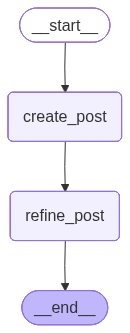

In [12]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image,display

graph = StateGraph(graph_schema)

graph.add_node("create_post", create_post)
graph.add_node("refine_post", refine_post)


graph.add_edge(START, "create_post")
graph.add_edge("create_post", "refine_post")
graph.add_edge("refine_post", END)

messaged_graph = graph.compile()

Image(messaged_graph.get_graph().draw_mermaid_png())

In [13]:
messaged_graph.invoke({"messages_manual": [HumanMessage(content="Write a linkedin post about the topic: AI")]})

KeyError: 'messages_manual'